## Swish Analytics Football Challenge - Modeling

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
    confusion_matrix
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
pd.set_option('display.max_rows', None)

### Inputs

In [4]:
df = pd.read_csv("../outputs/merged_pbp_roster_2021_2023.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62126 entries, 0 to 62125
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   old_game_id                 62126 non-null  int64  
 1   play_id                     62126 non-null  int64  
 2   home_team                   62126 non-null  object 
 3   away_team                   62126 non-null  object 
 4   season                      62126 non-null  int64  
 5   season_type                 62126 non-null  object 
 6   week                        62126 non-null  int64  
 7   posteam                     62126 non-null  object 
 8   yardline_100                62126 non-null  float64
 9   half_seconds_remaining      62126 non-null  float64
 10  game_seconds_remaining      62126 non-null  float64
 11  game_half                   62126 non-null  object 
 12  down                        61841 non-null  float64
 13  ydstogo                     621

In [7]:
df.columns

Index(['old_game_id', 'play_id', 'home_team', 'away_team', 'season',
       'season_type', 'week', 'posteam', 'yardline_100',
       'half_seconds_remaining', 'game_seconds_remaining', 'game_half', 'down',
       'ydstogo', 'play_type', 'shotgun', 'no_huddle', 'qb_dropback',
       'posteam_timeouts_remaining', 'defteam_timeouts_remaining',
       'posteam_score', 'defteam_score', 'score_differential', 'fg_prob',
       'td_prob', 'wp', 'sack', 'passer_player_id', 'passer_player_name', 'cp',
       'roof', 'wind', 'rolling_qb_sack_rate', 'rolling_offense_sack_rate',
       'rolling_defense_sack_rate', 'full_name', 'team', 'position', 'height',
       'weight', 'years_exp'],
      dtype='object')

In [89]:
logistic_features = ['season_type', 'yardline_100','game_seconds_remaining', 'game_half', 'down',
       'ydstogo', 'shotgun', 'no_huddle', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining',
       'score_differential', 'fg_prob','td_prob', 'wp', 'roof', 'wind', 'rolling_qb_sack_rate', 
       'rolling_offense_sack_rate','rolling_defense_sack_rate', 'height','weight', 'years_exp']

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


The logistic regression is affected more so by highly correlated features so we've removed things like possession team score and defensive team score since score differential is already included. For something like XG Boost, it's nice to have them all because the score differential can have different impacts at different scores.

In [90]:
xg_features = ['season', 'sack', 'season_type', 'yardline_100','half_seconds_remaining', 'game_seconds_remaining', 
        'game_half', 'down','ydstogo', 'shotgun', 'no_huddle', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining',
       'posteam_score', 'defteam_score', 'score_differential', 'fg_prob',
       'td_prob', 'wp', 'roof', 'wind', 'rolling_qb_sack_rate', 'rolling_offense_sack_rate',
       'rolling_defense_sack_rate', 'height','weight', 'years_exp']

### Logistic Regression

In [91]:
logistic_df = df.copy()
logistic_df = logistic_df[logistic_features + [target] + ['season']].copy()

In [92]:
logistic_df.isnull().sum().sort_values(ascending=False)

wind                          29107
years_exp                       707
weight                          707
height                          707
down                            285
rolling_qb_sack_rate            203
rolling_defense_sack_rate        32
rolling_offense_sack_rate        32
season_type                       0
wp                                0
sack                              0
roof                              0
td_prob                           0
yardline_100                      0
fg_prob                           0
score_differential                0
defteam_timeouts_remaining        0
posteam_timeouts_remaining        0
no_huddle                         0
shotgun                           0
ydstogo                           0
game_half                         0
game_seconds_remaining            0
season                            0
dtype: int64

In [93]:
# wind missing primarily because of domes/closed roofs
logistic_df['wind'] = logistic_df['wind'].fillna(0)

# rolling features missing for first observations
logistic_df['rolling_qb_sack_rate'] = (
    logistic_df['rolling_qb_sack_rate'].fillna(
        logistic_df['sack'].mean()
    )
)

logistic_df['rolling_offense_sack_rate'] = (
    logistic_df['rolling_offense_sack_rate'].fillna(
        logistic_df['sack'].mean()
    )
)

logistic_df['rolling_defense_sack_rate'] = (
    logistic_df['rolling_defense_sack_rate'].fillna(
        logistic_df['sack'].mean()
    )
)

# roster attributes
for col in ['height', 'weight', 'years_exp']:
    logistic_df[col] = logistic_df[col].fillna(
        logistic_df[col].median()
    )

# down
logistic_df['down'] = logistic_df['down'].fillna(
    logistic_df['down'].mode()[0]
)

In [94]:
categorical_cols = [
    'season_type',
    'game_half',
    'roof'
]

logistic_df = pd.get_dummies(
    logistic_df,
    columns=categorical_cols,
    drop_first=True
)

In [95]:
logistic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62126 entries, 0 to 62125
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   yardline_100                62126 non-null  float64
 1   game_seconds_remaining      62126 non-null  float64
 2   down                        62126 non-null  float64
 3   ydstogo                     62126 non-null  int64  
 4   shotgun                     62126 non-null  int64  
 5   no_huddle                   62126 non-null  int64  
 6   posteam_timeouts_remaining  62126 non-null  float64
 7   defteam_timeouts_remaining  62126 non-null  float64
 8   score_differential          62126 non-null  float64
 9   fg_prob                     62126 non-null  float64
 10  td_prob                     62126 non-null  float64
 11  wp                          62126 non-null  float64
 12  wind                        62126 non-null  float64
 13  rolling_qb_sack_rate        621

In [96]:
train_df = logistic_df[logistic_df['season'] < 2023]
test_df = logistic_df[logistic_df['season'] == 2023]

In [97]:
X_train = train_df.drop(columns=['sack', 'season'])
y_train = train_df['sack']

X_test = test_df.drop(columns=['sack', 'season'])
y_test = test_df['sack']

In [98]:
numeric_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [99]:
logistic_df['sack'].mean()

0.06647780317419438

In [100]:
log_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [101]:
y_pred = log_model.predict(X_test)

y_pred_proba = log_model.predict_proba(X_test)[:, 1]

In [102]:
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, y_pred_proba):.4f}")

ROC AUC: 0.6071
Log Loss: 0.2502
Brier Score: 0.0649


- We will not focus on accuracy and confusion matrix because sack events are so rare that our model predicts a non sack on literally every play. What's more important is the probability even if it is still always below 50%.
- **ROC interpretation:** Given one random sack and one random non-sack, the model ranks the sack play higher about 61% of the time.
- **Log loss interpreation:** the higher the value the worse your model's performance is. For example, a sack probability of 10% and a sack probability of 1% are both wrong if there was actually an observed sack - but the sack probability of 10% is penalized less. Can use this to compare to what we get from the XG Boost model. The baseline log loss if we plugged in the league average sack rate over this period (6.65%) would be 0.255.
- **Brier score:** (predicted probability - actual outcome) ^ 2 averaged over all plays. This Brier score is very similar to what we would've got if we predicted the league average sack rate over this period (6.65%) for every play.

In [103]:
coef_df = (
    pd.DataFrame({
        'feature': X_train.columns,
        'coefficient': log_model.coef_[0]
    })
    .sort_values('coefficient', ascending=False)
)

coef_df.head(15)

,feature,coefficient
2,down,0.314150
0,yardline_100,0.074574
24,roof_outdoors,0.072555
14,rolling_offense_sack_rate,0.068445
8,score_differential,0.059318
3,ydstogo,0.058712
10,td_prob,0.058070
15,rolling_defense_sack_rate,0.036711
13,rolling_qb_sack_rate,0.023290
22,roof_dome,0.022155


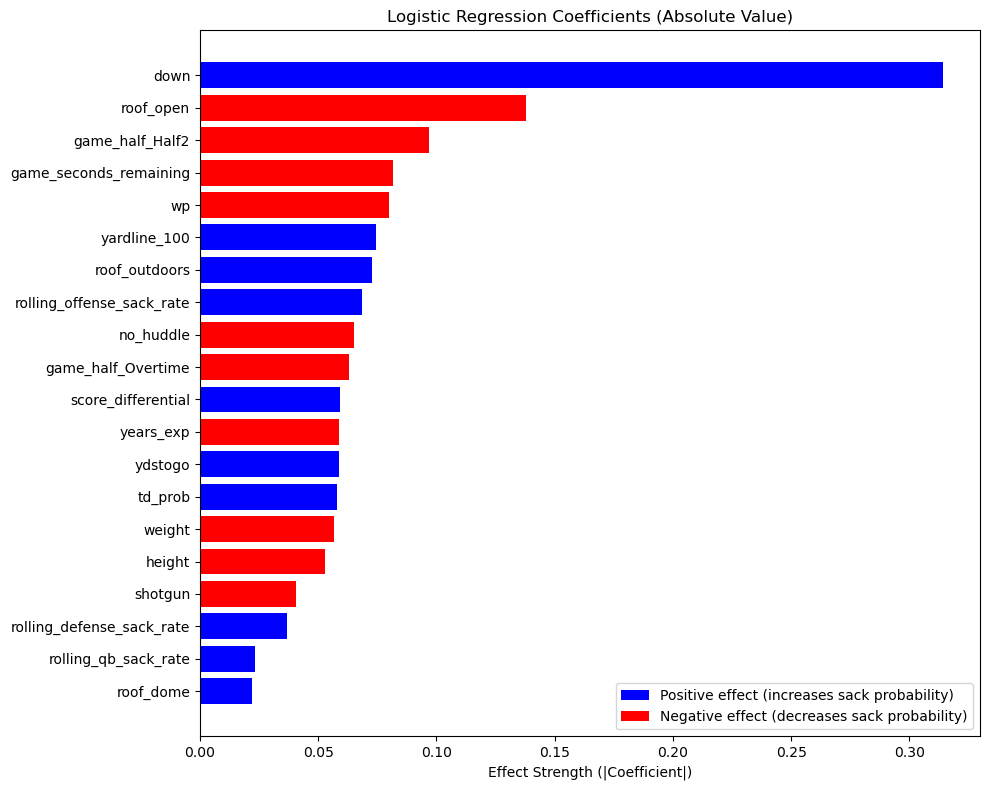

In [104]:
top_features = pd.concat([
    coef_df.head(10),
    coef_df.tail(10)
])

# Sort by absolute value so biggest effects are most visible
top_features = top_features.copy()
top_features['abs_coef'] = top_features['coefficient'].abs()
top_features = top_features.sort_values('abs_coef')

# Colors: red for negative, blue for positive
colors = top_features['coefficient'].apply(
    lambda x: 'red' if x < 0 else 'blue'
)

plt.figure(figsize=(10,8))

plt.barh(
    top_features['feature'],
    top_features['abs_coef'],
    color=colors
)

plt.title('Logistic Regression Coefficients (Absolute Value)')
plt.xlabel('Effect Strength (|Coefficient|)')

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='Positive effect (increases sack probability)'),
    Patch(facecolor='red', label='Negative effect (decreases sack probability)')
]

plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

### XG Boost

In [105]:
xgb_df = df[xg_features].copy()

categorical_cols = [
    'season_type',
    'game_half',
    'roof'
]

xgb_df = pd.get_dummies(
    xgb_df,
    columns=categorical_cols,
    drop_first=True
)

In [106]:
train_df = xgb_df[xgb_df['season'] < 2023]
test_df = xgb_df[xgb_df['season'] == 2023]

X_train = train_df.drop(columns=['sack', 'season'])
X_test = test_df.drop(columns=['sack', 'season'])

y_train = train_df['sack']
y_test = test_df['sack']

In [107]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [108]:
y_pred = xgb_model.predict(X_test)

y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

In [112]:
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, y_pred_proba):.4f}")

ROC AUC: 0.6134
Log Loss: 0.2495
Brier Score: 0.0647


In [110]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(
    'importance',
    ascending=False
)

importance_df.head(20)

,feature,importance
3,down,0.118729
4,ydstogo,0.042253
0,yardline_100,0.036059
12,fg_prob,0.035347
17,rolling_offense_sack_rate,0.035189
16,rolling_qb_sack_rate,0.035110
13,td_prob,0.035043
20,weight,0.035023
21,years_exp,0.034474
6,no_huddle,0.033807


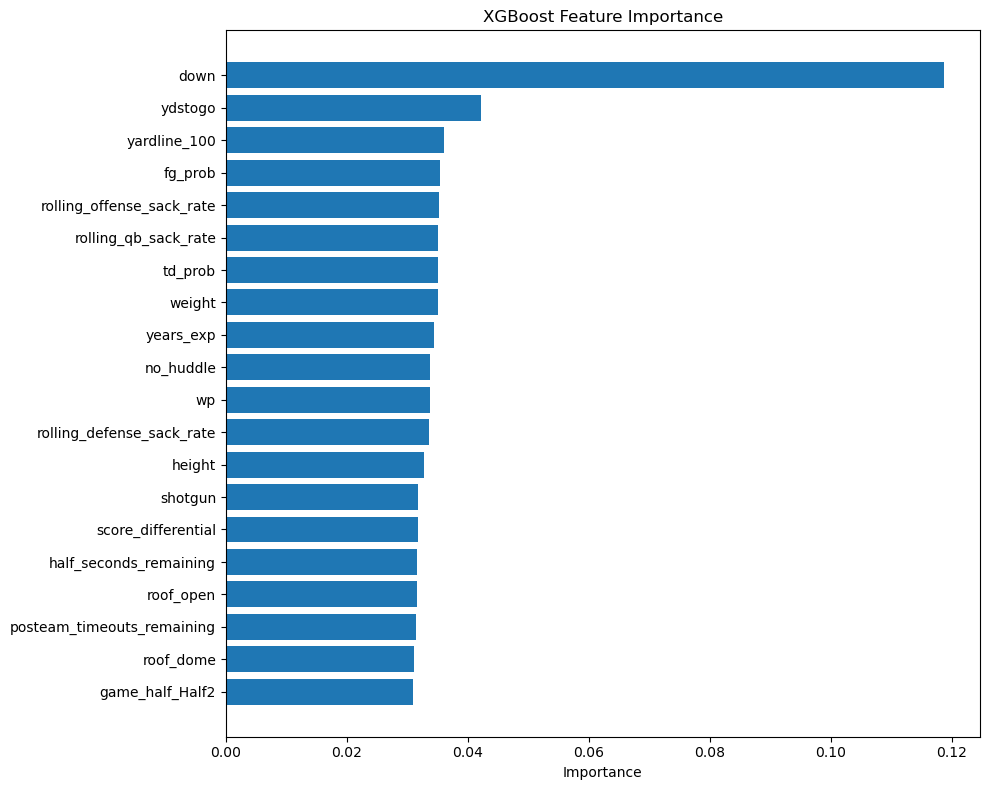

In [111]:
top_features = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_features['feature'][::-1],
    top_features['importance'][::-1]
)

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

I initially ran this model with completion probability as well, not knowing if it was pre or post snap data. However, it was by the far the most important feature and led to an ROC score of almost 0.98, which validated to me that this feature is a post snap feature. Removing completion probability reduced model performance substantially, suggesting that the variable contained information highly predictive of sacks. Because completion probability is itself a modeled statistic, it may contain information unavailable before the snap and therefore was excluded from the final model.

After removing this cp, logistic regression and XGBoost produced similar performance, with ROC AUC values around 0.61. This suggests that the remaining features primarily contain weak, additive relationships rather than strong nonlinear interactions.